<a href="https://colab.research.google.com/github/benjaaam0/Preprocesamiento_de_datos/blob/main/Actividad_con_decimas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("most_valuable_teams (1).csv")
df.head()

,Club,Competition,Age,Squad_size,Market_value,Market_value_of_players,MV_Top_18_players,Share_of_MV
0,Manchester City,Premier League,27.2,23,€1.05bn,€45.75m,€988.00m,93.9 %
1,Paris Saint-Germain,Ligue 1,26.1,35,€997.75m,€28.51m,€889.00m,89.1 %
2,Manchester United,Premier League,28.0,28,€937.25m,€33.47m,€850.00m,90.7 %
3,Chelsea FC,Premier League,26.8,27,€882.50m,€32.69m,€816.00m,92.5 %
4,Liverpool FC,Premier League,27.0,27,€879.50m,€32.57m,€810.50m,92.2 %


In [ ]:
# Función para limpiar y convertir los valores monetarios a millones de euros
def clean_value(val_str):
    val_str = str(val_str).replace('€', '')
    if 'bn' in val_str:
        return float(val_str.replace('bn', '')) * 1000  # Convertimos 'bn' a millones
    elif 'm' in val_str:
        return float(val_str.replace('m', ''))
    elif 'k' in val_str:
        return float(val_str.replace('k', '')) / 1000
    else:
        return pd.to_numeric(val_str, errors='coerce')

# Aplicamos la limpieza a las columnas correspondientes
df['Market_value_m'] = df['Market_value'].apply(clean_value)
df['Market_value_of_players_m'] = df['Market_value_of_players'].apply(clean_value)
df['MV_Top_18_players_m'] = df['MV_Top_18_players'].apply(clean_value)
df['Share_of_MV_pct'] = df['Share_of_MV'].str.replace(' %', '').astype(float)

# Verificamos los nuevos tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Club                       100 non-null    object 
 1   Competition                100 non-null    object 
 2   Age                        100 non-null    float64
 3   Squad_size                 100 non-null    int64  
 4   Market_value               100 non-null    object 
 5   Market_value_of_players    100 non-null    object 
 6   MV_Top_18_players          100 non-null    object 
 7   Share_of_MV                100 non-null    object 
 8   Market_value_m             100 non-null    float64
 9   Market_value_of_players_m  100 non-null    float64
 10  MV_Top_18_players_m        100 non-null    float64
 11  Share_of_MV_pct            100 non-null    float64
dtypes: float64(5), int64(1), object(6)
memory usage: 9.5+ KB


In [ ]:
# Obtenemos la estadística descriptiva
desc_stats = df[['Age', 'Squad_size', 'Market_value_m', 'Market_value_of_players_m', 'MV_Top_18_players_m', 'Share_of_MV_pct']].describe()
print(desc_stats)

             Age  Squad_size  Market_value_m  Market_value_of_players_m  \
count  100.00000   100.00000       100.00000                 100.000000   
mean    26.30800    27.54000       292.69270                  10.852200   
std      1.39499     2.87244       230.95511                   8.848602   
min     23.10000    21.00000        93.50000                   2.920000   
25%     25.40000    26.00000       126.62500                   4.695000   
50%     26.25000    27.00000       202.92500                   7.570000   
75%     27.42500    29.00000       359.18750                  13.922500   
max     29.90000    35.00000      1050.00000                  45.750000   

       MV_Top_18_players_m  Share_of_MV_pct  
count           100.000000       100.000000  
mean            270.750800        92.418000  
std             213.423125         3.010399  
min              84.950000        83.700000  
25%             118.250000        90.575000  
50%             185.450000        92.400000  
75

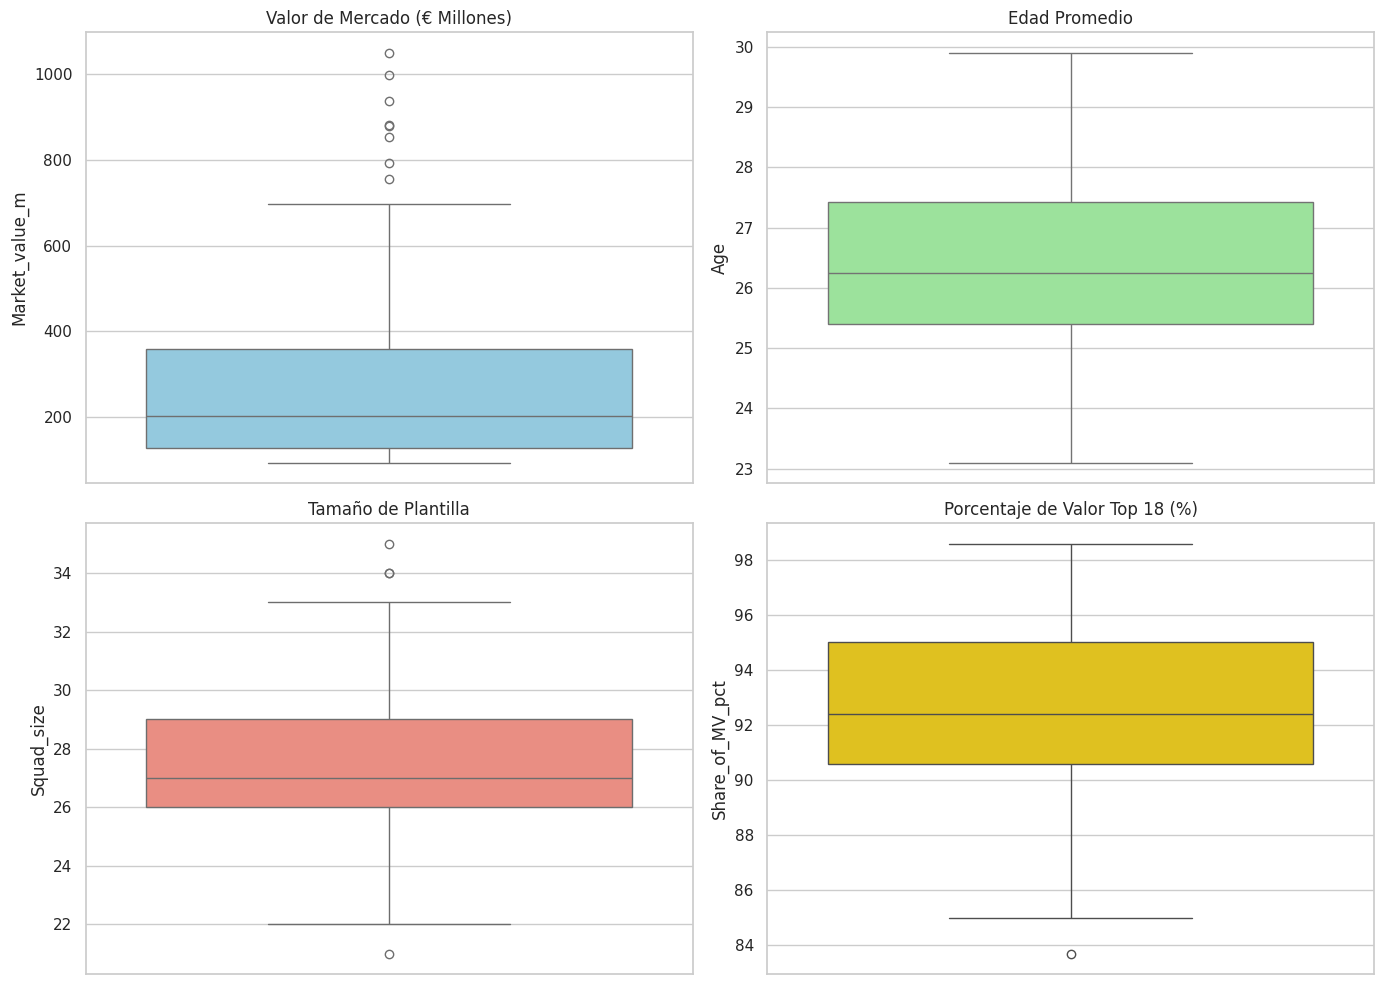

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=df['Market_value_m'], ax=axes[0, 0], color='skyblue').set_title('Valor de Mercado (€ Millones)')
sns.boxplot(y=df['Age'], ax=axes[0, 1], color='lightgreen').set_title('Edad Promedio')
sns.boxplot(y=df['Squad_size'], ax=axes[1, 0], color='salmon').set_title('Tamaño de Plantilla')
sns.boxplot(y=df['Share_of_MV_pct'], ax=axes[1, 1], color='gold').set_title('Porcentaje de Valor Top 18 (%)')

plt.tight_layout()
plt.show()

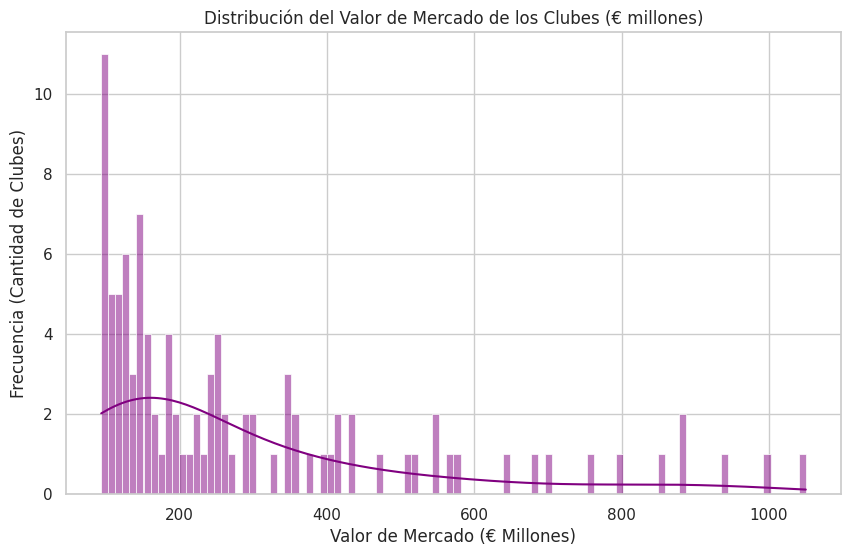

/tmp/ipykernel_15157/2936144768.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Market_value_m', y='Club', data=top_10, palette='viridis')


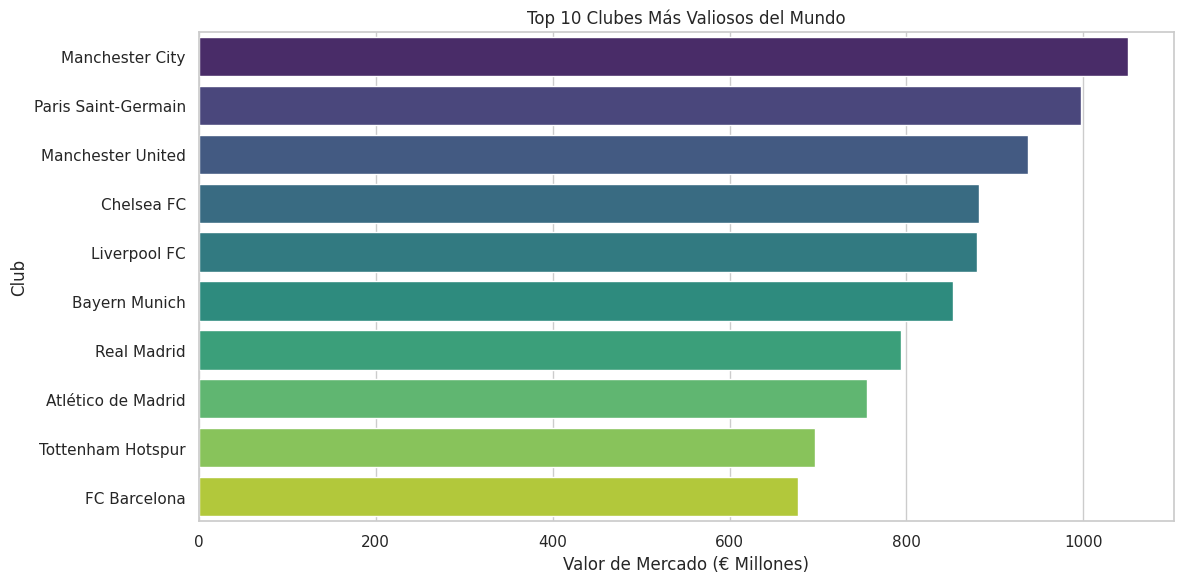

In [ ]:
# Histograma de la Distribución del Valor de Mercado
plt.figure(figsize=(10, 6))
sns.histplot(df['Market_value_m'], bins=100, kde=True, color='purple')
plt.title('Distribución del Valor de Mercado de los Clubes (€ millones)')
plt.xlabel('Valor de Mercado (€ Millones)')
plt.ylabel('Frecuencia (Cantidad de Clubes)')
plt.show()

# Gráfico de Barras: Top 10 Clubes Más Valiosos
top_10 = df.nlargest(10, 'Market_value_m')

plt.figure(figsize=(12, 6))
sns.barplot(x='Market_value_m', y='Club', data=top_10, palette='viridis')
plt.title('Top 10 Clubes Más Valiosos del Mundo')
plt.xlabel('Valor de Mercado (€ Millones)')
plt.ylabel('Club')
plt.tight_layout()
plt.show()